<a href="https://colab.research.google.com/github/dodi-ctrl/PhishingDetector/blob/main/Metadata_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dodi-ctrl/PhishingDetector/blob/main/Metadata_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metadata Agent — Multi-Corpus Training

Trains the Random Forest metadata agent on **real RFC 2822 headers** from three sources:

| Source | Label | Provides |
|---|---|---|
| `phishing_pot` (GitHub) | phishing (1) | full headers, modern 2022–2024 captures |
| Nazario `phishing3.mbox` (filtered ≥2022) | phishing (1) | full headers from honeypot |
| Enron ham via HuggingFace | legitimate (0) | body + subject; minimal envelope reconstructed |

This replaces the prior MeAJOR-only approach where SPF/DKIM/DMARC/Received features were all zero.

In [10]:
# Install dependencies
!pip install -q datasets scikit-learn pandas numpy matplotlib seaborn joblib
print("Installation OK")

Installation OK


In [11]:
# Clone the repo to get feature_extraction.py, dataset_handling.py, metadata_agent.py
import os

if not os.path.exists('PhishingDetector'):
    !git clone https://github.com/dodi-ctrl/PhishingDetector.git

os.chdir('PhishingDetector')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Cloning into 'PhishingDetector'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 85 (delta 47), reused 56 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 109.11 KiB | 1.19 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Working directory: /content/PhishingDetector/PhishingDetector
Files: ['.gitignore', '.git', 'Data Sets Update.docx', 'url_agent.py', 'URL_Agent.ipynb', 'metadata_agent.py', 'email_preprocessing.py', 'feature_extraction.py', 'dataset_handling.py', 'Metadata_Agent.ipynb', 'DistilBERT_Phishing_Text_Agent.ipynb']


## Download phishing corpora

- **phishing_pot**: cloned from GitHub — thousands of recent .eml files in `phishing_pot/email/`.
- **Nazario phishing3.mbox**: ~3,000 phishing messages collected by José Nazario.
- **Enron ham** is fetched on demand from HuggingFace inside `build_eml_corpus`.

In [12]:
# Download phishing_pot (.eml directory) and Nazario phishing3.mbox
import os

if not os.path.exists('phishing_pot'):
    !git clone --depth 1 https://github.com/rf-peixoto/phishing_pot.git

if not os.path.exists('phishing3.mbox'):
    !wget -q https://monkey.org/~jose/phishing/phishing3.mbox

print('phishing_pot exists:', os.path.exists('phishing_pot'))
print('phishing3.mbox exists:', os.path.exists('phishing3.mbox'))
if os.path.exists('phishing_pot'):
    for sub in ('email', 'emails'):
        p = os.path.join('phishing_pot', sub)
        if os.path.isdir(p):
            n = len([f for f in os.listdir(p) if f.endswith('.eml')])
            print(f'  {p}: {n} .eml files')

Cloning into 'phishing_pot'...
remote: Enumerating objects: 7919, done.
remote: Counting objects: 100% (7919/7919), done.
remote: Compressing objects: 100% (6132/6132), done.
remote: Total 7919 (delta 1796), reused 6589 (delta 1783), pack-reused 0 (from 0)
Receiving objects: 100% (7919/7919), 126.93 MiB | 27.65 MiB/s, done.
Resolving deltas: 100% (1796/1796), done.
Updating files: 100% (7916/7916), done.
phishing_pot exists: True
phishing3.mbox exists: True
  phishing_pot/email: 7911 .eml files


In [13]:
# Build the unified .eml corpus
from dataset_handling import build_eml_corpus, extract_metadata_features_from_eml_corpus
from feature_extraction import FeatureExtractor

# phishing_pot stores emails under phishing_pot/email/ (singular).
# Pass both candidate paths so the loader picks whichever exists.
PHISHING_DIRS = ['phishing_pot/email', 'phishing_pot/emails']
PHISHING_MBOX = ['phishing3.mbox']
ENRON_MAX     = 5000

eml_df = build_eml_corpus(
    phishing_dirs=PHISHING_DIRS,
    phishing_mbox_paths=PHISHING_MBOX,
    enron_max=ENRON_MAX,
    nazario_after_year=2022,
)


BUILDING EML CORPUS (phishing_pot + Nazario + Enron)
  Loaded 7911 .eml files from phishing_pot/email (label=1)
  Loaded 1 messages from phishing3.mbox (label=1)
  Loading Enron ham from HuggingFace (SetFit/enron_spam)...


Repo card metadata block was not found. Setting CardData to empty.


  Loaded 5000 Enron ham emails (label=0)

✓ EML corpus built:
  Phishing:   7912
  Legitimate: 5000
  Total:      12912
  Sources:    {'phishing_pot': 7911, 'enron': 5000, 'nazario': 1}


In [14]:
# Extract metadata features from real headers
extractor = FeatureExtractor()
features_df, labels = extract_metadata_features_from_eml_corpus(eml_df, extractor)

print('\nFeature matrix shape:', features_df.shape)
print('First 5 features:', list(features_df.columns[:5]))


EXTRACTING METADATA FEATURES FROM EML CORPUS
  Processed 500/12912 emails...
  Processed 1000/12912 emails...
  Processed 1500/12912 emails...
  Processed 2000/12912 emails...
  Processed 2500/12912 emails...
  Processed 3000/12912 emails...
  Processed 3500/12912 emails...
  Processed 4000/12912 emails...
  Processed 4500/12912 emails...
  Processed 5000/12912 emails...
  Processed 5500/12912 emails...
  Processed 6000/12912 emails...
  Processed 6500/12912 emails...
  Processed 7000/12912 emails...
  Processed 7500/12912 emails...
  Processed 8000/12912 emails...
  Processed 8500/12912 emails...
  Processed 9000/12912 emails...
  Processed 9500/12912 emails...
  Processed 10000/12912 emails...
  Processed 10500/12912 emails...
  Processed 11000/12912 emails...
  Processed 11500/12912 emails...
  Processed 12000/12912 emails...
  Processed 12500/12912 emails...

✓ Extracted 37 metadata features from 12912 emails

Feature matrix shape: (12912, 37)
First 5 features: ['sender_domain_len

In [15]:
# Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_df, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"  - Legitimate:   {(y_test == 0).sum()}")
print(f"  - Phishing:     {(y_test == 1).sum()}")

Training samples: 9038
Test samples:     3874
  - Legitimate:   1500
  - Phishing:     2374


In [16]:
# Train the Metadata Agent
from metadata_agent import MetadataAgent

agent = MetadataAgent(n_estimators=100, max_depth=20, random_state=42)
agent.train(X_train, y_train, validate=True, tune_hyperparameters=False)


TRAINING METADATA AGENT (Random Forest)

Performing 5-fold cross-validation...
Cross-validation Accuracy: 0.9998 (+/- 0.0009)
Cross-validation F1-Score: 0.9998 (+/- 0.0007)

----------------------------------------------------------------------
TOP 15 MOST IMPORTANT METADATA FEATURES
----------------------------------------------------------------------
mime_version_1_0                    0.232970
has_mime_version                    0.196301
num_received_headers                0.136121
num_x_headers                       0.108042
suspicious_ip_count                 0.103988
message_id_domain_mismatch          0.042534
sender_domain_length                0.036952
spf_none                            0.035278
dmarc_none                          0.026891
is_multipart                        0.025414
is_html                             0.018593
spf_pass                            0.009992
return_path_mismatch                0.008503
dkim_none                           0.006283
sender_has_su


METADATA AGENT PERFORMANCE EVALUATION

Accuracy:  0.9992 (99.92%)
Precision: 1.0000 (100.00%)
Recall:    0.9987 (99.87%)
F1-Score:  0.9994 (99.94%)
ROC-AUC:   1.0000

False Positive Rate (FPR): 0.0000 (0.00%)
False Negative Rate (FNR): 0.0013 (0.13%)
True Negative Rate (TNR):  1.0000 (100.00%)

----------------------------------------------------------------------
CONFUSION MATRIX
----------------------------------------------------------------------
                Predicted Legit Predicted Phishing
Actual Legit               1500                  0
Actual Phishing               3               2371

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate     0.9980    1.0000    0.9990      1500
    Phishing     1.0000    0.9987    0.9994      2374

    accuracy                         0.9992      3874

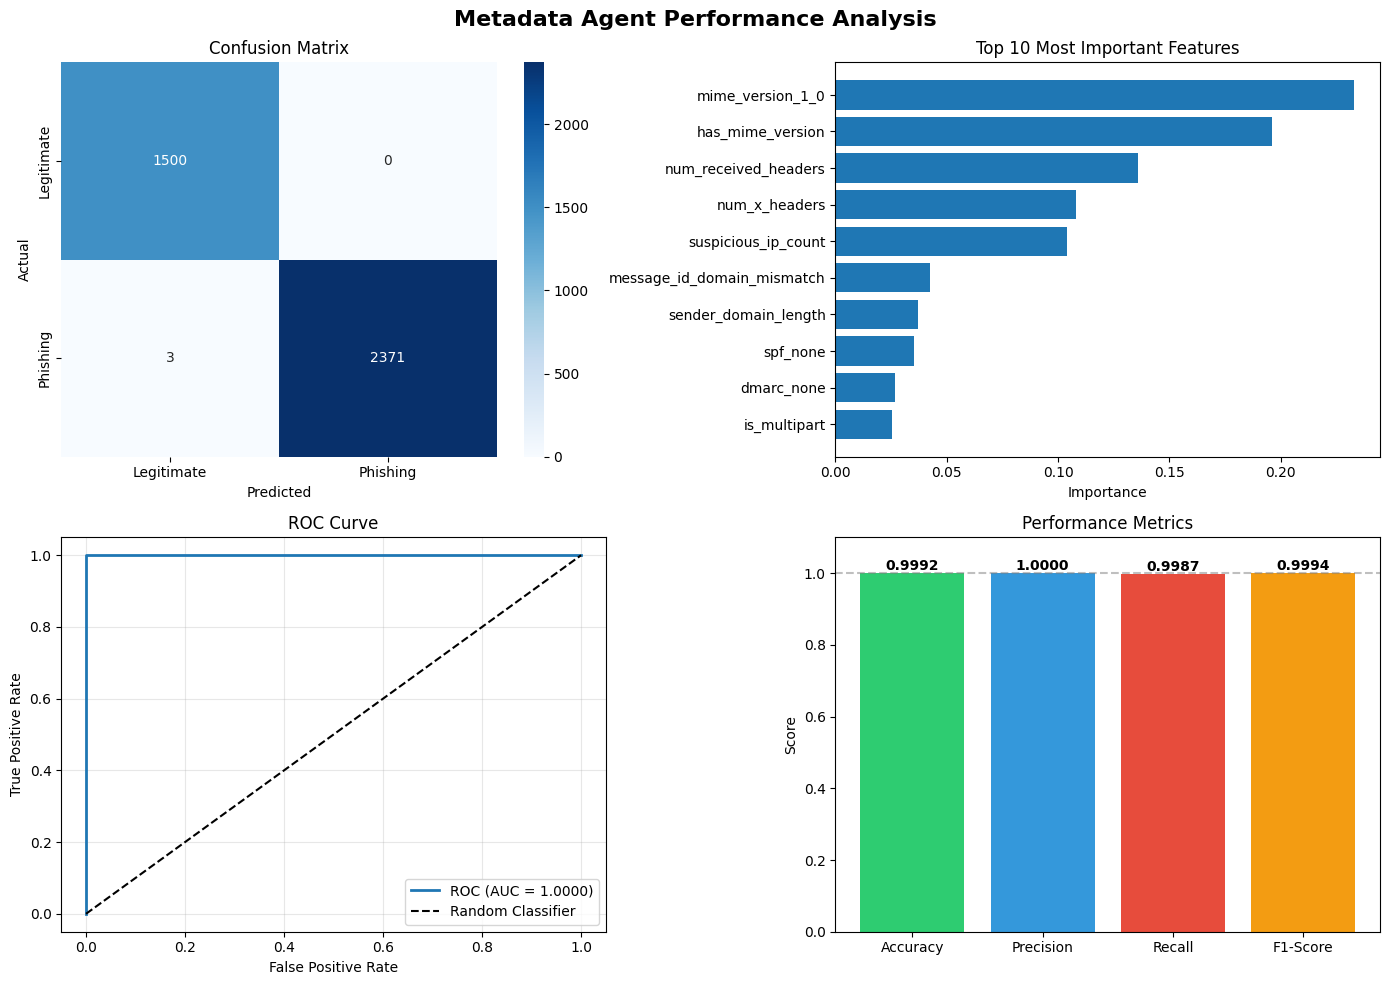

In [17]:
# Evaluate — accuracy, precision, recall, F1, ROC-AUC, FPR/FNR/TNR,
# confusion matrix, classification report, and plots
results = agent.evaluate(X_test, y_test, plot_results=True)

In [18]:
# Save model and results
agent.save_model('metadata_agent.pkl')
agent.export_results(results, 'metadata_agent_results.json')

print('\n' + '=' * 70)
print('Training complete!')
print(f"  Accuracy:  {results['accuracy']:.4f}")
print(f"  F1-Score:  {results['f1_score']:.4f}")
print(f"  ROC-AUC:   {results['roc_auc']:.4f}")
print('=' * 70)


✓ Model saved successfully to: metadata_agent.pkl

✓ Results exported to: metadata_agent_results.json

Training complete!
  Accuracy:  0.9992
  F1-Score:  0.9994
  ROC-AUC:   1.0000
